# Baseline 1 — CHS (2008) reduced-form hazard model

Campbell, Hilscher & Szilagyi (2008, *JF*) logit on eight variables — the standard
academic benchmark for bankruptcy prediction. Its role in the paper is to show
where the academic literature stands before adding features, nonlinearity, or
network information.

**Specification.** Pooled logit of `default_next_hq` on:

| Variable | Definition |
|---|---|
| NIMTA | net income / (market equity + total liabilities) |
| TLMTA | total liabilities / (market equity + total liabilities) |
| EXRET | log return minus log S&P 500 return (quarterly) |
| SIGMA | annualized stock return volatility |
| RSIZE | log(firm market equity / total market equity) |
| CASHMTA | cash & equivalents / (market equity + total liabilities) |
| MB | market-to-book (CHS 10% book-equity adjustment) |
| PRICE | log(price), capped at \$15 |

Variables are built from raw Compustat quarterly + CRSP monthly files in
[`chs_features.py`](chs_features.py) and cached; deviations from the original
monthly/daily construction (quarterly EXRET, 12-month monthly-return SIGMA,
total-CRSP RSIZE denominator) are documented there.

**Training protocol: walk-forward.** Every model is trained with an expanding
window and annual refit anchors 2007–2025 ([`walk_forward.py`](walk_forward.py)):
the model scoring calendar year Y is fit only on rows whose h-quarter label
window closed before Y began (`datadate ≤ Y-01-01 − horizon days`), per horizon
h = 1..8. Scores therefore exist for 2007+ only, and all of 2007–2025 is
out-of-sample. Scores are cached per model/horizon
(`results/models/wf_scores_<model>.parquet`); delete a cache to retrain.

Labels for h ∈ {1, 4, 8} come from phase4; intermediate horizons are rebuilt
with the identical rule and validated at load time. Each horizon's evaluation
sample is right-censored separately. Reported windows: **val-era 2007–2012**
and **test 2013–2025** (for XGBoost models, hyperparameters and tree counts are
selected on 2007–2012, so treat that window accordingly; 2013+ is untouched by
any selection).

CHS has no hyperparameters, so each refit anchor is fully point-in-time:
winsorization bounds (5th/95th), the scaler, and the coefficients are all
re-estimated on that anchor's training window.

**Merton distance-to-default variant:** the 53-feature set does *not* include a
Merton DD measure, so that classic-benchmark variant is left as future work
(it would need an iterative KMV solve on equity value/volatility).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import baseline_utils as bu
import chs_features as chs
import walk_forward as wf

panel = bu.load_panel()
print(panel.shape)

# positives per horizon in the (per-horizon censored) evaluation windows
pd.DataFrame({
    h: panel.loc[bu.horizon_mask(panel, h)].groupby('split')[bu.label_col(h)].sum()
    for h in bu.HORIZONS
}).loc[['train', 'val', 'test']].astype(int)

(1540221, 80)


,1,2,3,4,5,6,7,8
split,,,,,,,,
train,391,929,1527,2133,2758,3567,4449,5408
val,117,321,570,826,1092,1373,1653,1922
test,171,423,710,1031,1377,1720,2047,2360


In [2]:
# Build (or load cached) CHS variables; keep complete cases
chs_vars = chs.build_chs_variables(panel[['gvkey', 'datadate', 'permno']])
label_cols = [bu.label_col(h) for h in bu.HORIZONS]
df = panel[['gvkey', 'datadate', 'year', 'quarter', 'split'] + label_cols].merge(
    chs_vars, on=['gvkey', 'datadate'], how='left')

coverage = df.groupby('split')[chs.CHS_VARS].apply(lambda g: g.notna().all(axis=1).mean())
print('share of rows with all 8 CHS variables, by split:')
print(coverage.round(3))
df = df.dropna(subset=chs.CHS_VARS).reset_index(drop=True)
df.groupby('split')[bu.LABEL_COL].agg(['size', 'sum', 'mean'])

share of rows with all 8 CHS variables, by split:
split
pretrain    0.506
test        0.610
train       0.635
val         0.629
dtype: float64


,size,sum,mean
split,,,
pretrain,210225,477,0.002269
test,209304,450,0.002150
train,386274,847,0.002193
val,108830,395,0.003630


In [3]:
# Walk-forward scores (cached per horizon) and per-horizon metrics
scores = wf.build_chs_wf_scores(df)
df = df.merge(scores, on=['gvkey', 'datadate'], how='left')
df = df.rename(columns={f'chs_logit_wf_h{h}': f'score_h{h}' for h in bu.HORIZONS})

def wf_metrics(frame, h):
    mh = bu.horizon_mask(frame, h)
    out = {}
    for s in ['val', 'test']:
        sub = frame[mh & (frame['split'] == s)]
        out[s] = bu.evaluate_scores(sub[bu.label_col(h)].values,
                                    sub[f'score_h{h}'].values)
    return pd.DataFrame(out).T

metrics_by_h = {h: wf_metrics(df, h) for h in bu.HORIZONS}
for h in bu.HORIZONS:
    m = metrics_by_h[h]
    print(f"h={h}q  test ROC-AUC={m.loc['test', 'roc_auc']:.4f}  "
          f"PR-AUC={m.loc['test', 'pr_auc']:.4f}  ({int(m.loc['test', 'n_pos'])} pos)")
print()
print('primary horizon (4q):')
metrics_by_h[bu.PRIMARY_HORIZON].round(4)

  chs_logit_wf_h1: cached


  chs_logit_wf_h2: cached


  chs_logit_wf_h3: cached


  chs_logit_wf_h4: cached


  chs_logit_wf_h5: cached


  chs_logit_wf_h6: cached


  chs_logit_wf_h7: cached


  chs_logit_wf_h8: cached


h=1q  test ROC-AUC=0.7618  PR-AUC=0.0220  (43 pos)
h=2q  test ROC-AUC=0.7109  PR-AUC=0.0370  (142 pos)
h=3q  test ROC-AUC=0.7387  PR-AUC=0.0483  (281 pos)
h=4q  test ROC-AUC=0.7555  PR-AUC=0.0560  (450 pos)
h=5q  test ROC-AUC=0.7636  PR-AUC=0.0646  (648 pos)
h=6q  test ROC-AUC=0.7669  PR-AUC=0.0735  (852 pos)
h=7q  test ROC-AUC=0.7697  PR-AUC=0.0751  (1046 pos)
h=8q  test ROC-AUC=0.7710  PR-AUC=0.0788  (1229 pos)

primary horizon (4q):


,n,n_pos,base_rate,roc_auc,pr_auc,capture_top1pct,capture_top5pct,capture_top10pct
val,108830.0,395.0,0.0036,0.6283,0.0327,0.1620,0.4177,0.5139
test,209304.0,450.0,0.0021,0.7555,0.0560,0.3578,0.6000,0.6911


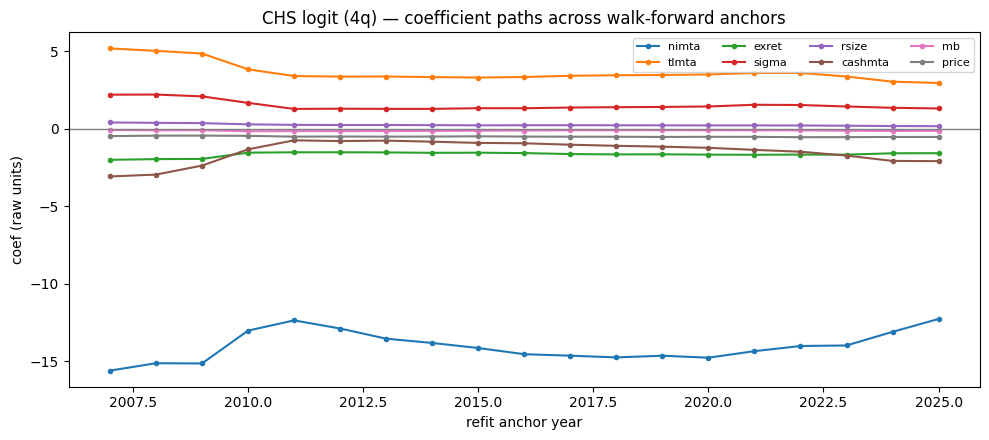

,"coef (2025 anchor, raw units)",CHS 2008 sign,sign match
nimta,-12.2725,-,True
tlmta,2.9532,+,True
exret,-1.5766,-,True
sigma,1.3088,+,True
rsize,0.1652,-,False
cashmta,-2.0925,-,True
mb,-0.1347,+,False
price,-0.5288,-,True


In [4]:
# Coefficient paths across refit anchors (4q), and signs vs CHS (2008)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

coef_by_anchor = {}
for anchor in wf.ANCHORS:
    cutoff = wf.embargo_cutoff(anchor, bu.PRIMARY_HORIZON)
    tr = df[(df['year'] >= wf.TRAIN_START) & (df['datadate'] <= cutoff)]
    lo, hi = tr[chs.CHS_VARS].quantile(0.05), tr[chs.CHS_VARS].quantile(0.95)
    X = tr[chs.CHS_VARS].clip(lower=lo, upper=hi, axis=1).values
    scaler = StandardScaler().fit(X)
    logit = LogisticRegression(C=1e6, max_iter=2000)
    logit.fit(scaler.transform(X), tr[bu.LABEL_COL].values)
    coef_by_anchor[anchor] = pd.Series(logit.coef_[0] / scaler.scale_,
                                       index=chs.CHS_VARS)
coef_paths = pd.DataFrame(coef_by_anchor).T

fig, ax = plt.subplots(figsize=(10, 4.5))
for v in chs.CHS_VARS:
    ax.plot(coef_paths.index, coef_paths[v], marker='.', label=v)
ax.axhline(0, color='gray', lw=1)
ax.set_title('CHS logit (4q) — coefficient paths across walk-forward anchors')
ax.set_xlabel('refit anchor year'); ax.set_ylabel('coef (raw units)')
ax.legend(fontsize=8, ncol=4)
plt.tight_layout(); plt.show()

chs_2008_signs = {'nimta': '-', 'tlmta': '+', 'exret': '-', 'sigma': '+',
                  'rsize': '-', 'cashmta': '-', 'mb': '+', 'price': '-'}
last = coef_paths.iloc[-1]
pd.DataFrame({
    f'coef ({coef_paths.index[-1]} anchor, raw units)': last,
    'CHS 2008 sign': [chs_2008_signs[v] for v in chs.CHS_VARS],
    'sign match': [('+' if last[v] > 0 else '-') == chs_2008_signs[v]
                   for v in chs.CHS_VARS],
}).round(4)

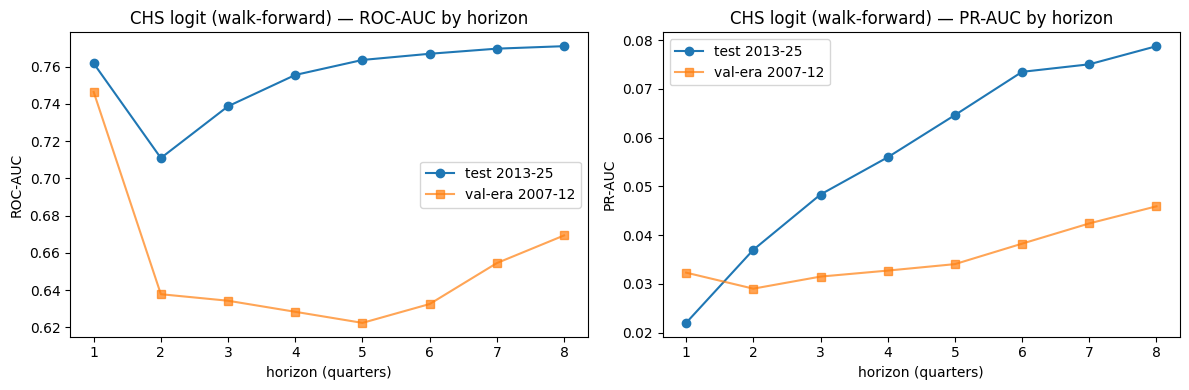

,test ROC-AUC,val-era ROC-AUC,test PR-AUC,val-era PR-AUC
1,0.7618,0.7464,0.0220,0.0323
2,0.7109,0.6377,0.0370,0.0290
3,0.7387,0.6342,0.0483,0.0315
4,0.7555,0.6283,0.0560,0.0327
5,0.7636,0.6223,0.0646,0.0341
6,0.7669,0.6325,0.0735,0.0383
7,0.7697,0.6545,0.0751,0.0424
8,0.7710,0.6693,0.0788,0.0459


In [5]:
# Term structure of discrimination
ts = pd.DataFrame({
    h: {'test ROC-AUC': metrics_by_h[h].loc['test', 'roc_auc'],
        'val-era ROC-AUC': metrics_by_h[h].loc['val', 'roc_auc'],
        'test PR-AUC': metrics_by_h[h].loc['test', 'pr_auc'],
        'val-era PR-AUC': metrics_by_h[h].loc['val', 'pr_auc']}
    for h in bu.HORIZONS
}).T

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ['ROC-AUC', 'PR-AUC']):
    ax.plot(ts.index, ts[f'test {metric}'], marker='o', label='test 2013-25')
    ax.plot(ts.index, ts[f'val-era {metric}'], marker='s', alpha=0.7,
            label='val-era 2007-12')
    ax.set_xlabel('horizon (quarters)'); ax.set_ylabel(metric); ax.legend()
    ax.set_title(f'CHS logit (walk-forward) — {metric} by horizon')
plt.tight_layout(); plt.show()
ts.round(4)

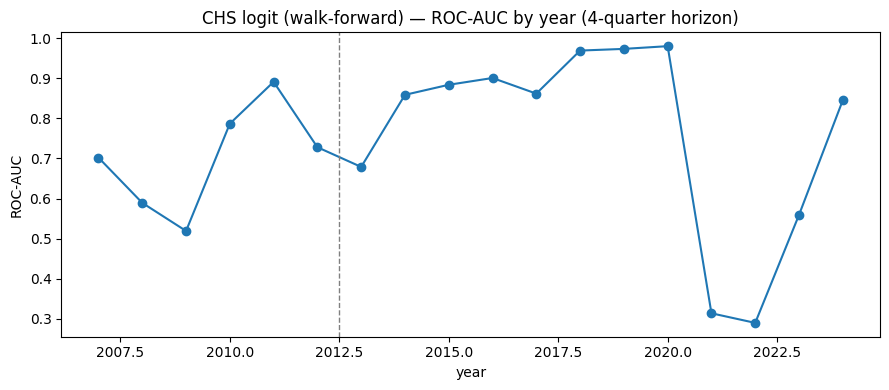

,n,n_pos,roc_auc,pr_auc
2007,19684.0,55.0,0.7021,0.0451
2008,19260.0,175.0,0.5893,0.0444
2009,18116.0,93.0,0.5192,0.0305
2010,17523.0,20.0,0.7868,0.0295
2011,17280.0,30.0,0.8913,0.0567
2012,16967.0,22.0,0.7281,0.0845
2013,16773.0,28.0,0.6789,0.0836
2014,17177.0,32.0,0.8588,0.2367
2015,17526.0,62.0,0.8839,0.2088
2016,17095.0,34.0,0.9008,0.1667


In [6]:
# Discrimination by year at the primary horizon
by_year = bu.evaluate_by_year(df[bu.horizon_mask(df, 4)], 'score_h4')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(by_year.index, by_year['roc_auc'], marker='o')
ax.axvline(2012.5, color='gray', ls='--', lw=1)
ax.set_title('CHS logit (walk-forward) — ROC-AUC by year (4-quarter horizon)')
ax.set_xlabel('year'); ax.set_ylabel('ROC-AUC')
plt.tight_layout(); plt.show()
by_year[['n', 'n_pos', 'roc_auc', 'pr_auc']].round(4)

In [7]:
# Persist per-horizon metrics + walk-forward scores
score_cols = [f'score_h{h}' for h in bu.HORIZONS]
out = bu.save_results(
    'chs_logit',
    {f'h{h}': {s: metrics_by_h[h].loc[s].to_dict() for s in ['val', 'test']}
     for h in bu.HORIZONS},
    predictions=df[['gvkey', 'datadate', 'split'] + score_cols],
    extra={'protocol': 'walk-forward, annual anchors 2007-2025, label embargo',
           'coefficients_final_anchor': last.to_dict(),
           'notes': 'One logit per anchor x horizon; winsorization, scaler and '
                    'coefficients re-estimated per anchor. No Merton DD variant '
                    '(distance-to-default not in the feature set).'},
)
print('saved ->', out)

saved -> /Users/GabrielReisen/Desktop/Credit Contagion Network/results/models/chs_logit_metrics.json
